<a href="https://colab.research.google.com/github/alexklupsch/alexklupsch.github.io/blob/main/multi_label.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi Label Image Classification -- UCM airborne images -- Land Cover Classification

This notebook goes through our first attempt at handling the problem of a multi label classification of airborne images.

Inputs are 2100 images of the size 256x256p with a resolution of 0.3m, labeled by hand with 17 land cover classes. It is a relabeling of the original UCM dataset which consisted of a 100 images per single label class for 21 classes.

## 1. Data Loading and Preparation

In [2]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 32.5 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
from PIL import Image
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
from lightning.pytorch import LightningModule, Trainer
from lightning.pytorch.callbacks import BackboneFinetuning
from lightning.pytorch.loggers import WandbLogger

In [4]:
## loading the data and directory handling
! git clone https://git.wur.nl/lobry001/ucmdata.git
os.chdir('ucmdata')

with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
  zip_ref.extractall('UCMImages')

!mv UCMImages/UCMerced_LandUse/Images .
!rm -rf UCMImages README.md UCMerced_LandUse.zip
!ls

UCM_images_path = "Images/"
Multilabels_path = "LandUse_Multilabeled.txt"

Cloning into 'ucmdata'...
remote: Enumerating objects: 8, done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 8 (from 1)
Receiving objects: 100% (8/8), 316.99 MiB | 19.88 MiB/s, done.
Images	LandUse_Multilabeled.txt


In [7]:
import pandas as pd

# loading the labels
path = "/content/ucmdata/LandUse_Multilabeled.txt"
df = pd.read_csv(path, sep="\t", header=0)

In [9]:
df.head()

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


<Axes: xlabel='Count', ylabel='class'>

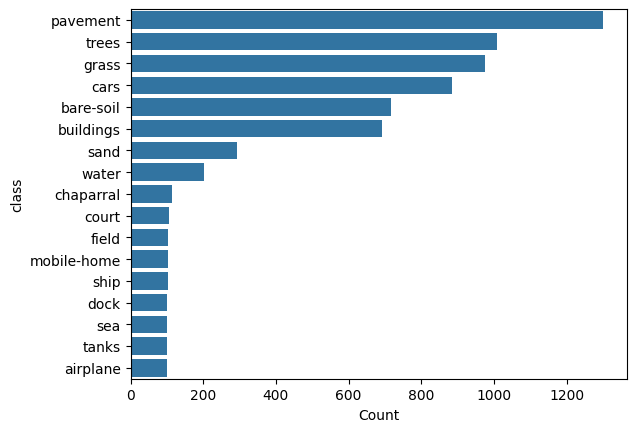

In [19]:
import seaborn as sns
# calc and plot the class count -> taken from medium post
class_count = pd.DataFrame(df.sum(axis=0)).reset_index()
class_count.columns = ["class", "Count"]
class_count.drop(class_count.index[0], inplace=True)
class_count = class_count.sort_values(by="Count", ascending=False)

sns.barplot(class_count, x="Count", y="class")


In [38]:
## Accessing the images
dir = "/content/ucmdata/Images"
image_dict = {} # dict for key:class, value: [image_paths]
labels_map = {} # dict for key:class_num, value: class_name

for class_num, class_name in enumerate(os.listdir(dir)):
  labels_map[class_num] = class_name
  class_dir = os.path.join(dir, class_name)

  if os.path.isdir(class_dir): # sort out *.txt-file
    for image in os.listdir(class_dir):
      image_path = os.path.join(class_dir, image)
      df.loc[df["IMAGE\\LABEL"] == image.split(sep=".")[0], ["path"]] = image_path # string matching, then save path in column

In [40]:
print(df["path"].notna().all())
df.head()

True


,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water,path
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,/content/ucmdata/Images/agricultural/agricultu...
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,/content/ucmdata/Images/agricultural/agricultu...


In [47]:
# reduce dataset to one hot encoding vectors
label_cols = df.columns.difference(["IMAGE\\LABEL", "path"])

# transfrom
labels = df[label_cols].values
paths = df["path"].values
dataset = [(path, label) for label, path in zip(labels, paths)]

In [54]:
############################
## NEED TO FINISH THIS STILL
############################


def split_train_test(dataset, val_ratio, test_ratio):

  random.seed(42) # to ensure the same test set for different models
  train_dataset = []
  val_dataset = []
  test_dataset = []

  random.shuffle(dataset)
  sample_length = len(dataset)

  test_split = int(sample_length * test_ratio)
  test_dataset.extend([(image, label) for image in i])
  for label, image_path in dataset:

    ## split off the test_dataset with the fixed random seed first to keep test set consistent
    test_split = int(sample_length * test_ratio)
    test_dataset.extend([(image, label) for image in image_paths[:test_split]])
    image_paths = image_paths[test_split:]

    ## reshuffle to mix up training and validation data for different runs
    random.seed()
    random.shuffle(image_paths)

    val_split = int(sample_length * val_ratio)

    val_dataset.extend([(image, label) for image in image_paths[:val_split]])
    train_dataset.extend([(image, label) for image in image_paths[val_split:]])

  return train_dataset, val_dataset, test_dataset

train_dataset,val_dataset, test_dataset = split_train_test(dataset, val_ratio = 0.15, test_ratio=0.15)

TypeError: 'str' object does not support item assignment

In [52]:
train_dataset

[]

In [50]:
def plot_first_per_class(data, index_to_class, cols=5, figsize=(15, 3)):

    # Collect first image per label
    first_image_per_label = {}
    for image_path, label in data:
        if label not in first_image_per_label:
            first_image_per_label[label] = image_path

    labels = sorted(first_image_per_label.keys())
    num_classes = len(labels)
    rows = (num_classes + cols - 1) // cols

    plt.figure(figsize=(figsize[0], figsize[1] * rows))

    for i, label in enumerate(labels):
        image_path = first_image_per_label[label]
        class_name = index_to_class.get(label, "unknown")

        with Image.open(image_path) as img:
            img = img.convert("RGB")

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"{label}: {class_name}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

In [51]:
plot_first_per_class(test_dataset, labels_map) ## should plot the same images in every project!!

<Figure size 1500x0 with 0 Axes>